# ResNet50 Transfer Learning

This notebook implements a transfer learning approach using ResNet50 for brain tumor MRI classification.

The goal is to compare ResNet50 with the baseline CNN and MobileNetV2 approaches under the same preprocessing and training conditions.

## Import Libraries

In this step, we import the required libraries and project modules needed to build and train the ResNet50 transfer learning model.

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.models as models
import matplotlib.pyplot as plt
import os
import sys
import random
import numpy as np
import warnings
warnings.filterwarnings("ignore")

sys.path.append(os.path.abspath(".."))

from src.dataset import BrainTumorDataset
from src.transforms import train_transform, test_transform
from src.trainer import train_model

## Reproducibility and Device Setup

We set a fixed random seed to make the results more reproducible.  
We also check whether CUDA is available so the model can be trained on the GPU.

In [38]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


##  Load Processed Dataset

In this step, we load the processed training and validation datasets generated during preprocessing.

These files contain image paths and their corresponding labels after splitting the dataset.

In [22]:
train_data = torch.load("../data/processed/train_split.pt")
val_data = torch.load("../data/processed/val_split.pt")

train_images, train_labels = train_data
val_images, val_labels = val_data

print("Training Images:", len(train_images))
print("Training Labels:", len(train_labels))
print("Validation Images:", len(val_images))
print("Validation Labels:", len(val_labels))

print("\nSample Label:", train_labels[0])

Training Images: 4000
Training Labels: 4000
Validation Images: 1000
Validation Labels: 1000

Sample Label: 1


## Fix Image Paths for Current Environment

The processed split files contain absolute image paths generated in another environment.

To make the notebook portable, we rebuild the image paths using the current project directory instead of depending on a specific username or server path.

In [39]:
PROJECT_DIR = os.path.abspath("..")

train_images = [
    os.path.join(PROJECT_DIR, "data", "raw", "train", *path.split("/data/raw/train/")[-1].split("/"))
    for path in train_images
]

val_images = [
    os.path.join(PROJECT_DIR, "data", "raw", "train", *path.split("/data/raw/train/")[-1].split("/"))
    for path in val_images
]

print("Image paths updated successfully.")

Image paths updated successfully.


## Create Dataset and DataLoader

In this step, we convert the image paths and labels into PyTorch Dataset objects and prepare DataLoaders for training and validation.

In [24]:
train_dataset = BrainTumorDataset(
    train_images,
    train_labels,
    transform=train_transform
)

val_dataset = BrainTumorDataset(
    val_images,
    val_labels,
    transform=test_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])


## Build ResNet50 Model

In this step, we define a ResNet50 model using transfer learning.  
The pretrained ResNet50 model is loaded from torchvision, and its final fully connected layer is replaced to match our four brain tumor classes.

In [37]:
def build_resnet():
    model = models.resnet50(
    weights=models.ResNet50_Weights.DEFAULT
)
    model.fc = nn.Linear(model.fc.in_features, 4)
    return model.to(device)

def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## Create Model Directory

In this step, we create a directory for saving the trained ResNet50 models.

In [26]:
BASE_DIR = os.path.abspath("..")
MODEL_DIR = os.path.join(BASE_DIR, "models")

os.makedirs(MODEL_DIR, exist_ok=True)

print("Model directory created successfully.")

Model directory created successfully.


## Baseline ResNet50: Frozen Feature Extractor

In this experiment, we use a pretrained ResNet50 model as a fixed feature extractor.

All convolutional layers are frozen, while only the final fully connected classification layer is trained on the MRI dataset.

In [27]:
model_base = build_resnet()

for param in model_base.parameters():
    param.requires_grad = False

for param in model_base.fc.parameters():
    param.requires_grad = True

print("Trainable Params:", count_trainable_params(model_base))

Trainable Params: 8196


## Train Baseline ResNet50

In this step, we train only the final classification layer of ResNet50 while keeping the feature extraction layers frozen.

In [28]:
criterion = nn.CrossEntropyLoss()
optimizer_base = optim.Adam(model_base.fc.parameters(), lr=0.0001)

baseline_path = os.path.join(MODEL_DIR, "resnet50_baseline.pth")

best_acc_base, history_base = train_model(
    model=model_base,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_base,
    epochs=5,
    device=device,
    model_path=baseline_path
)

print(f"Best Validation Accuracy: {best_acc_base:.4f}")

Model updated | Best Val Acc: 0.7660
Epoch [1/5]
Train Loss: 1.1731 | Train Acc: 0.5837
Val Loss: 0.9832 | Val Acc: 0.7660
--------------------------------------------------
Model updated | Best Val Acc: 0.8080
Epoch [2/5]
Train Loss: 0.8786 | Train Acc: 0.7825
Val Loss: 0.7774 | Val Acc: 0.8080
--------------------------------------------------
Model updated | Best Val Acc: 0.8250
Epoch [3/5]
Train Loss: 0.7253 | Train Acc: 0.8107
Val Loss: 0.6734 | Val Acc: 0.8250
--------------------------------------------------
Model updated | Best Val Acc: 0.8260
Epoch [4/5]
Train Loss: 0.6427 | Train Acc: 0.8197
Val Loss: 0.6068 | Val Acc: 0.8260
--------------------------------------------------
Model updated | Best Val Acc: 0.8370
Epoch [5/5]
Train Loss: 0.5904 | Train Acc: 0.8267
Val Loss: 0.5587 | Val Acc: 0.8370
--------------------------------------------------
Best Validation Accuracy: 0.8370


##  Plot Baseline ResNet50 Curves

In this step, we visualize the training and validation loss and accuracy for the frozen ResNet50 baseline model.

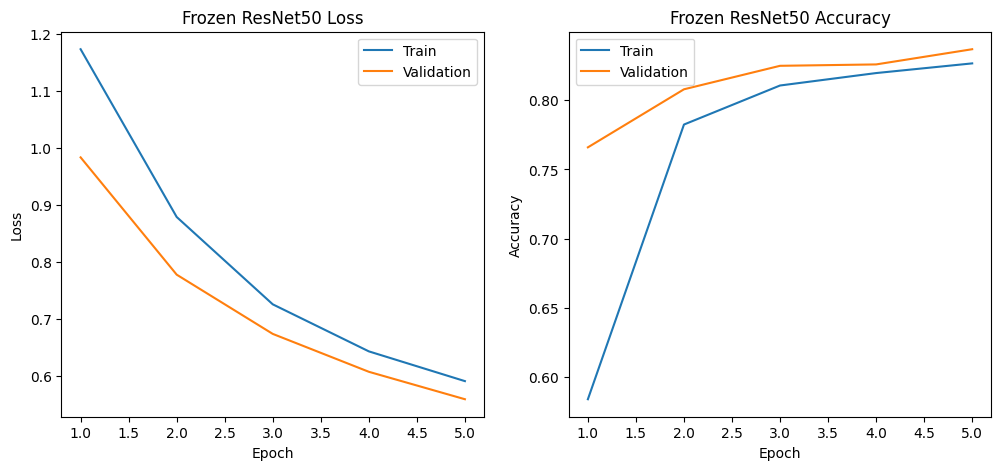

In [29]:
epochs = range(1, len(history_base["train_loss"]) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, history_base["train_loss"])
plt.plot(epochs, history_base["val_loss"])
plt.title("Frozen ResNet50 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])

plt.subplot(1, 2, 2)
plt.plot(epochs, history_base["train_acc"])
plt.plot(epochs, history_base["val_acc"])
plt.title("Frozen ResNet50 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])

plt.show()

## Experiment 1: Partial Fine-Tuning

In this experiment, we unfreeze the final ResNet50 block (`layer4`) while keeping the earlier layers frozen.

This allows the model to adapt higher-level image features to the MRI domain while still benefiting from pretrained ImageNet representations.

In [30]:
model_exp1 = build_resnet()

for param in model_exp1.parameters():
    param.requires_grad = False

for param in model_exp1.layer4.parameters():
    param.requires_grad = True

for param in model_exp1.fc.parameters():
    param.requires_grad = True

print("Trainable Params:", count_trainable_params(model_exp1))

Trainable Params: 14972932


##  Train Experiment 1

In this experiment, we fine-tune the last ResNet50 block (`layer4`) together with the final classification layer.

In [31]:
optimizer_exp1 = optim.Adam(
    filter(lambda p: p.requires_grad, model_exp1.parameters()),
    lr=0.0001
)

exp1_path = os.path.join(MODEL_DIR, "resnet50_partial_finetuning.pth")

best_acc_exp1, history_exp1 = train_model(
    model=model_exp1,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_exp1,
    epochs=5,
    device=device,
    model_path=exp1_path
)

print(f"Best Validation Accuracy: {best_acc_exp1:.4f}")

Model updated | Best Val Acc: 0.9600
Epoch [1/5]
Train Loss: 0.3088 | Train Acc: 0.8892
Val Loss: 0.1354 | Val Acc: 0.9600
--------------------------------------------------
Model updated | Best Val Acc: 0.9660
Epoch [2/5]
Train Loss: 0.1039 | Train Acc: 0.9633
Val Loss: 0.0903 | Val Acc: 0.9660
--------------------------------------------------
Model updated | Best Val Acc: 0.9700
Epoch [3/5]
Train Loss: 0.0703 | Train Acc: 0.9795
Val Loss: 0.0862 | Val Acc: 0.9700
--------------------------------------------------
Epoch [4/5]
Train Loss: 0.0489 | Train Acc: 0.9818
Val Loss: 0.0976 | Val Acc: 0.9680
--------------------------------------------------
Model updated | Best Val Acc: 0.9790
Epoch [5/5]
Train Loss: 0.0384 | Train Acc: 0.9875
Val Loss: 0.0712 | Val Acc: 0.9790
--------------------------------------------------
Best Validation Accuracy: 0.9790


##  Plot Experiment 1 Curves

In this step, we visualize the training and validation performance after partially fine-tuning the ResNet50 model.

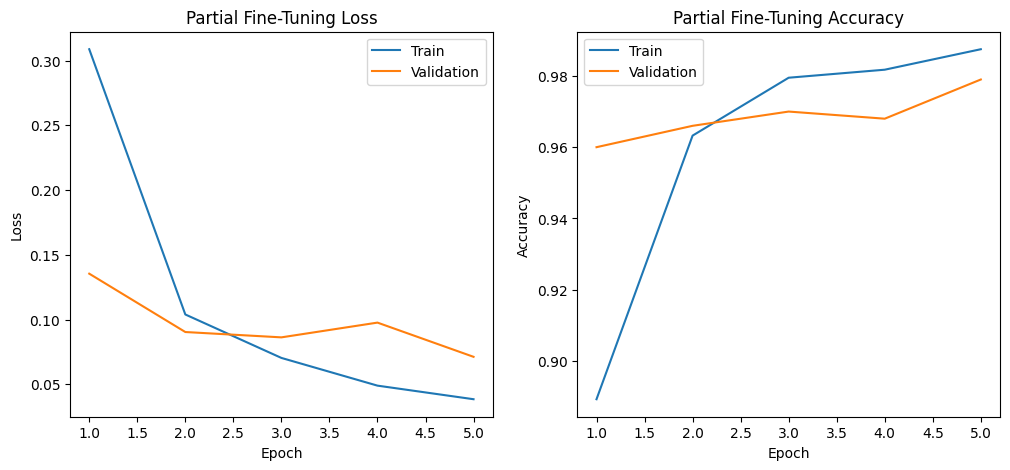

In [32]:
epochs = range(1, len(history_exp1["train_loss"]) + 1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs, history_exp1["train_loss"])
plt.plot(epochs, history_exp1["val_loss"])
plt.title("Partial Fine-Tuning Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])

plt.subplot(1,2,2)
plt.plot(epochs, history_exp1["train_acc"])
plt.plot(epochs, history_exp1["val_acc"])
plt.title("Partial Fine-Tuning Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])

plt.show()

##  Experiment 2: Deeper Fine-Tuning

In this experiment, we unfreeze both `layer3` and `layer4` of ResNet50, in addition to the final classification layer.

This gives the model more flexibility to adapt deeper feature representations to the MRI dataset.

In [33]:
model_exp2 = build_resnet()

for param in model_exp2.parameters():
    param.requires_grad = False

for param in model_exp2.layer3.parameters():
    param.requires_grad = True

for param in model_exp2.layer4.parameters():
    param.requires_grad = True

for param in model_exp2.fc.parameters():
    param.requires_grad = True

print("Trainable Params:", count_trainable_params(model_exp2))

Trainable Params: 22071300


##  Train Experiment 2

In this experiment, we fine-tune both `layer3` and `layer4` of ResNet50 together with the final classification layer.

In [34]:
optimizer_exp2 = optim.Adam(
    filter(lambda p: p.requires_grad, model_exp2.parameters()),
    lr=0.0001
)

exp2_path = os.path.join(MODEL_DIR, "resnet50_deep_finetuning.pth")

best_acc_exp2, history_exp2 = train_model(
    model=model_exp2,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_exp2,
    epochs=5,
    device=device,
    model_path=exp2_path
)

print(f"Best Validation Accuracy: {best_acc_exp2:.4f}")

Model updated | Best Val Acc: 0.9680
Epoch [1/5]
Train Loss: 0.2593 | Train Acc: 0.9113
Val Loss: 0.0925 | Val Acc: 0.9680
--------------------------------------------------
Model updated | Best Val Acc: 0.9760
Epoch [2/5]
Train Loss: 0.0867 | Train Acc: 0.9710
Val Loss: 0.0648 | Val Acc: 0.9760
--------------------------------------------------
Epoch [3/5]
Train Loss: 0.0686 | Train Acc: 0.9778
Val Loss: 0.0739 | Val Acc: 0.9730
--------------------------------------------------
Model updated | Best Val Acc: 0.9800
Epoch [4/5]
Train Loss: 0.0349 | Train Acc: 0.9900
Val Loss: 0.0630 | Val Acc: 0.9800
--------------------------------------------------
Model updated | Best Val Acc: 0.9840
Epoch [5/5]
Train Loss: 0.0195 | Train Acc: 0.9940
Val Loss: 0.0429 | Val Acc: 0.9840
--------------------------------------------------
Best Validation Accuracy: 0.9840



##  Plot Experiment 2 Curves

In this step, we visualize the training and validation performance after deeper fine-tuning of ResNet50.

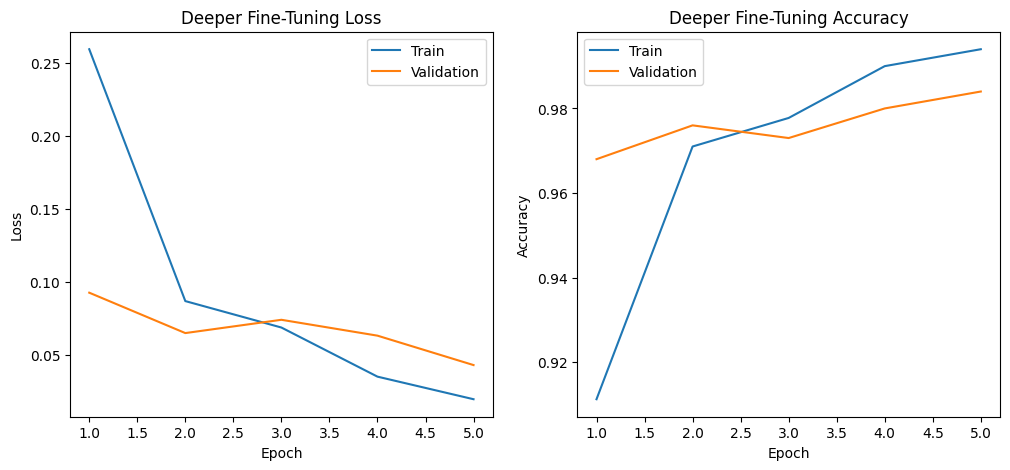

In [35]:
epochs = range(1, len(history_exp2["train_loss"]) + 1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs, history_exp2["train_loss"])
plt.plot(epochs, history_exp2["val_loss"])
plt.title("Deeper Fine-Tuning Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])

plt.subplot(1,2,2)
plt.plot(epochs, history_exp2["train_acc"])
plt.plot(epochs, history_exp2["val_acc"])
plt.title("Deeper Fine-Tuning Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])

plt.show()

##  Compare ResNet50 Results

In this step, we compare the validation accuracy of the three ResNet50 training strategies.

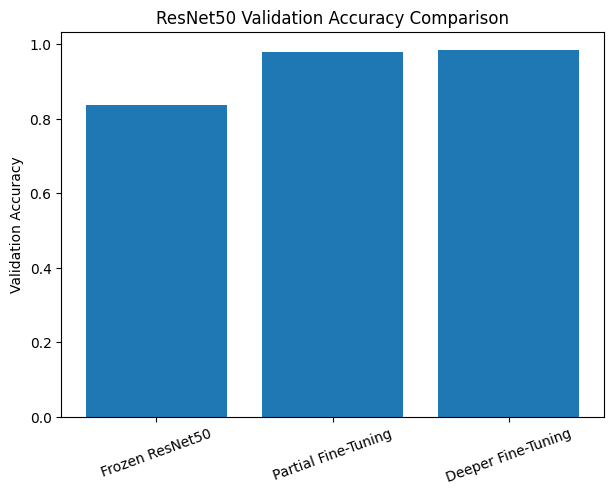

===== FINAL RESNET50 RESULTS =====
Frozen ResNet50 Accuracy: 0.8370
Partial Fine-Tuning Accuracy: 0.9790
Deeper Fine-Tuning Accuracy: 0.9840


In [36]:
models_names = ["Frozen ResNet50", "Partial Fine-Tuning", "Deeper Fine-Tuning"]
accuracies = [best_acc_base, best_acc_exp1, best_acc_exp2]

plt.figure(figsize=(7, 5))
plt.bar(models_names, accuracies)
plt.title("ResNet50 Validation Accuracy Comparison")
plt.ylabel("Validation Accuracy")
plt.xticks(rotation=20)
plt.show()

print("===== FINAL RESNET50 RESULTS =====")
print(f"Frozen ResNet50 Accuracy: {best_acc_base:.4f}")
print(f"Partial Fine-Tuning Accuracy: {best_acc_exp1:.4f}")
print(f"Deeper Fine-Tuning Accuracy: {best_acc_exp2:.4f}")

## Conclusion

In this notebook, we implemented ResNet50 transfer learning for brain tumor MRI classification.

We tested three training strategies:
- Frozen ResNet50 feature extractor
- Partial fine-tuning by unfreezing `layer4`
- Deeper fine-tuning by unfreezing `layer3` and `layer4`

The frozen ResNet50 baseline achieved a validation accuracy of 0.8370.  
Partial fine-tuning improved the validation accuracy to 0.9790.  
Deeper fine-tuning achieved the best validation accuracy of 0.9840.

These results show that fine-tuning deeper ResNet50 layers helps the model adapt better to MRI image features.  
The best ResNet50 model can later be compared with the baseline CNN and MobileNetV2 models.